In [1]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

In [2]:
# width = 1200
# height = 1800
# cutout_left = 900
# cutout_top = 800
width = 1500
height = 1500
cutout_left = 1000
cutout_top = 500

In [3]:
# map x and map y are the map coordinates.
# A map is a view projected over a real world area. 
# The 0, 0 world x, y could be anywhere within the map.
# Remember that the edges are all defined in world coordinates.

margin = 100

wx_range = np.arange(-margin, width + margin)
wy_range = np.arange(-margin, height + margin)
wx_map, wy_map = np.meshgrid(wx_range, wy_range, indexing='ij')
low_probability = 10 ** -10

In [4]:
def plot_map(map_data, axs=None, title=None):
    if axs is None:
        plt.figure(figsize=(8, 8))
        axs = plt.gca()
    if title is not None:
        axs.set_title(title)
    axs.imshow(
        map_data.T,
        cmap='gray',
        origin='lower',
        extent=[wx_range[0], wx_range[-1], wy_range[0], wy_range[-1]]
    )


## Building a distance boundary model

The distance boundary model is similar to the boundary model, instead of modelling if a point is within or outside the boundary, we are modelling if a reading mapping to a point would be on a boundary or not, again this is blurred for a probabilistic reading, given how we know our sensor never gives exact readings.

In [5]:
# We now need to define the edges of our arena and the cutout.
corners = np.array([
    (0, height),
    (width, height),
    (width, cutout_top),
    (cutout_left, cutout_top),
    (cutout_left, 0),
    (0, 0)
])

edges = np.array([
    [0, 1],
    [1, 2],
    [2, 3],
    [3, 4],
    [4, 5],
    [5, 0]
])

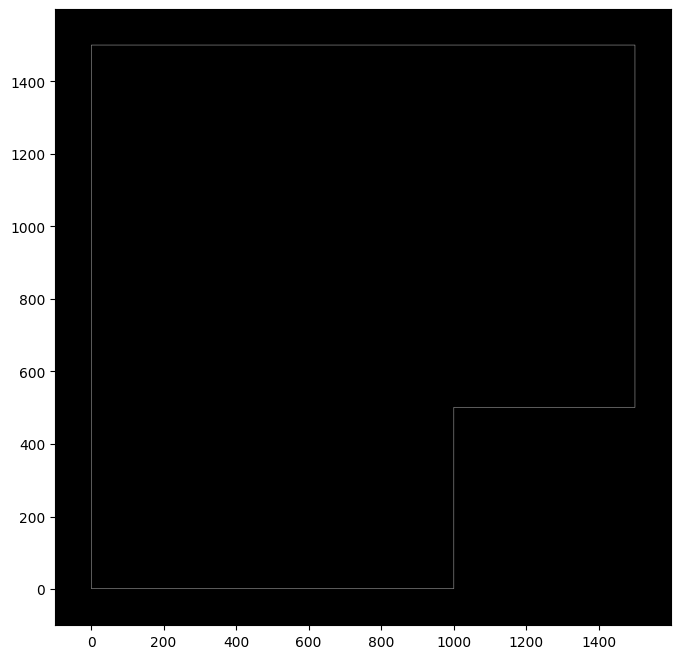

In [6]:
# Intially we draw the boundary with edges that are 1 mm wide
distance_field = np.zeros_like(wx_map, dtype=np.float32)
for edge in edges:
    p1 = corners[edge[0]] + (margin, margin)
    p2 = corners[edge[1]] + (margin, margin)
    cv2.line(distance_field, p1[::-1], p2[::-1], color=1, thickness=1)
# distance_field = distance_field
plot_map(distance_field)

(1700, 1700)

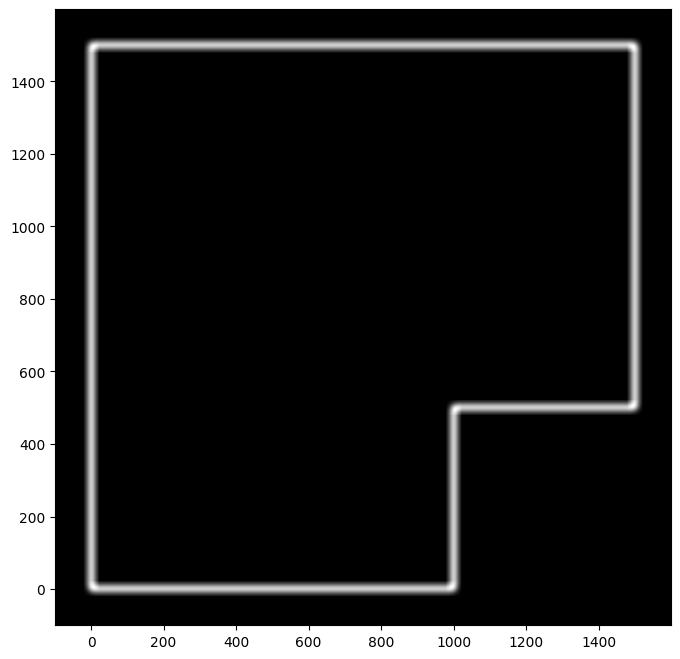

In [7]:
# Since our sensor will not exactly line up, we then blur this boundary into the probabilistic model
distance_span = 41 # This should be set to a value that matches our uncertainty about the sensor reading in mm
blurred_distance = cv2.GaussianBlur(distance_field, (distance_span, distance_span), 10)
plot_map(blurred_distance)
np.shape(blurred_distance)

In [8]:
blurred_distance[100, 100]

np.float32(0.04156866)

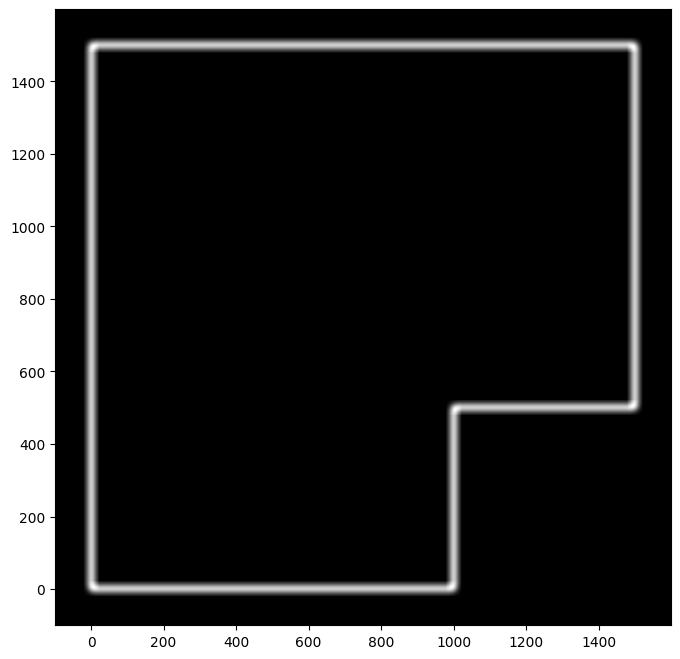

In [9]:
# Scale so every pixel is between 0 and 1
blurred_distance -= blurred_distance.min()
blurred_distance /= blurred_distance.max()
blurred_distance += low_probability
plot_map(blurred_distance)

In [10]:
np.max(blurred_distance)

np.float32(1.0)

In [11]:
blurred_distance[462,1699], blurred_distance[100,100]

(np.float32(1e-10), np.float32(0.8101491))

## Test data
Let's make some poses to test our model against.

## Testing sensor obervations against the distance boundary model

In [12]:
# Set up constants for the sensors
sensor_offset = 50,0.0 # mm
sensor_angles = np.linspace(-np.pi/8, np.pi/8, 8)  # 8 sensors from -22.5 to +22.5 degrees - 45 degrees.
sensor_direction_vectors = np.array([
    [np.cos(angle), np.sin(angle)] for angle in sensor_angles
])

The sensor_offset - this is where the sensor surface is located relative to the robot center. In this case, the sensor is 50mm units in front of the robot center.

In [16]:
input_readings = np.array([562,556,545,539,434,375,397,334]) # mm - 8 readings taken from row 5 in chapter 8 data.

In [19]:
# We have 8 measurements - lets process them into coordinates
def sensor_readings_to_coordinates(sensor_readings):
    return sensor_direction_vectors * sensor_readings[:, np.newaxis] + sensor_offset

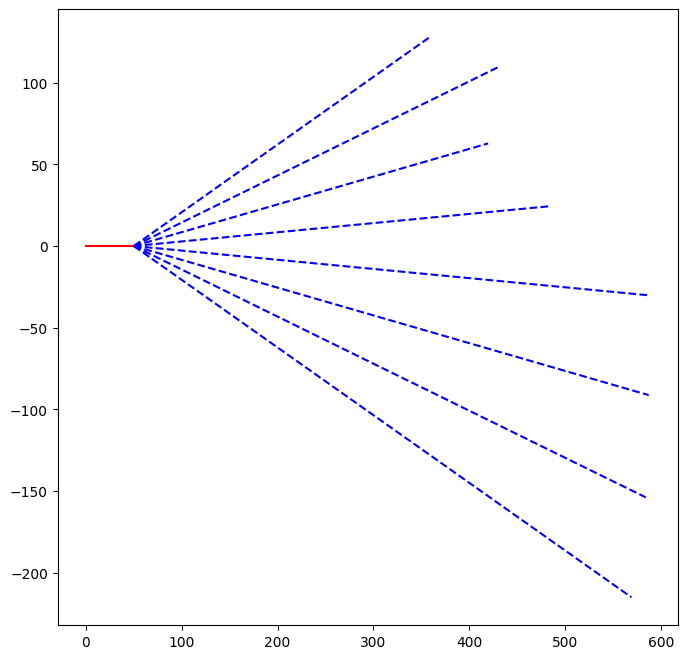

In [23]:
sensor_reading_coordinates = sensor_readings_to_coordinates(input_readings)
# Lets plot this
plt.figure(figsize=(8, 8))
plt.plot([0, sensor_offset[0]], [0, sensor_offset[1]], 'r-')
for coordinate in sensor_reading_coordinates:
    plt.plot([sensor_offset[0], coordinate[0]], [sensor_offset[1], coordinate[1]], 'b--')

In [12]:
population_size = 20000
rng = np.random.default_rng()
poses = np.column_stack((
            rng.uniform(0, width, population_size),
            rng.uniform(0, height, population_size),
            rng.uniform(0, 2 * np.pi, population_size)
        ))

In [17]:
# The sensor coordinates are a set of local points (local to the pose). We can make a function transform a set of points to be relative to the poses
# This would go into the common poses.py as a utility function
def transform_points_to_poses(local_points, poses):
    # local points is a list of local points, n points times (x, y)
    # poses is m poses times (x, y, theta)
    # we want to return all points transformed to each pose - so m poses times n points times (x, y)
    poses_x, poses_y, poses_theta = poses[:,0], poses[:,1], poses[:,2]
    cos_th = np.cos(poses_theta)[:, None, None]
    sin_th = np.sin(poses_theta)[:, None, None]
    # Rotate all local points for each pose - rotation(pose theta) * sensor coordinates
    points_x = local_points[:,0]
    points_y = local_points[:,1]
    rotated_x = cos_th * points_x - sin_th * points_y
    rotated_y = sin_th * points_x + cos_th * points_y
    # Now translate all rotated points for each pose, stack back into x, y pairs
    return np.stack( 
        [
            rotated_x + poses_x[:, np.newaxis],
            rotated_y + poses_y[:, np.newaxis]
        ], axis=-1
    )

# sensor_coordinates_in_poses = transform_points_to_poses(sensor_reading_coordinates, poses)

In [68]:
# Lets try a small number of poses
try_poses = poses[0:2]

# Decompose
poses_x, poses_y, poses_theta = try_poses[:,0], try_poses[:,1], try_poses[:,2]
try_poses, poses_x, poses_y, poses_theta


(array([[1242.81508843,  442.25104022,    2.86651645],
        [ 943.32441592,   26.44727072,    4.45564088]]),
 array([1242.81508843,  943.32441592]),
 array([442.25104022,  26.44727072]),
 array([2.86651645, 4.45564088]))

In [69]:
# Get the rotations for these
cos_th = np.cos(poses_theta)#[:, None, None]
sin_th = np.sin(poses_theta)#[:, None, None]
cos_th, sin_th

(array([-0.9624045 , -0.25393659]), array([ 0.27162028, -0.96722087]))

(-1.0, 1.0)

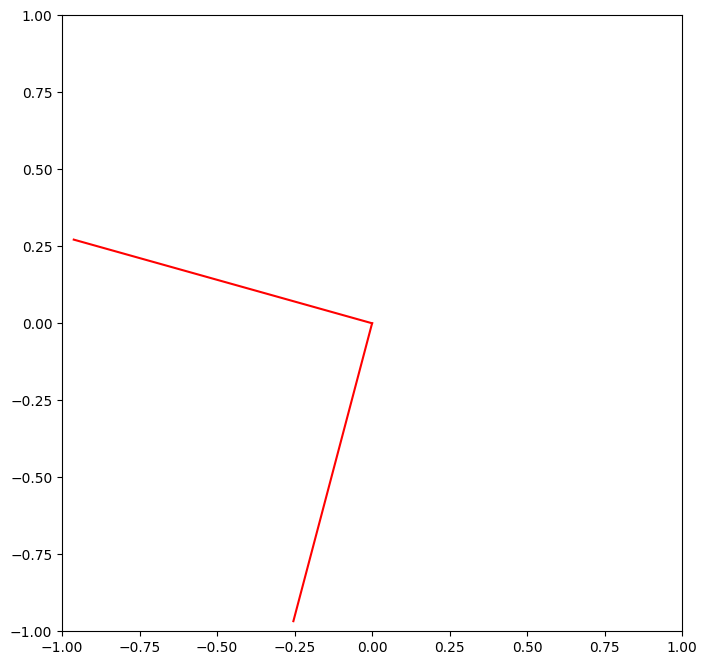

In [71]:
# PLot this as a unit plot
plt.figure(figsize=(8, 8))
for pose, ct, st in zip(try_poses, cos_th, sin_th):
    plt.plot([0, ct], [0, st], 'r-')
plt.xlim(-1, 1)
plt.ylim(-1, 1)

In [72]:
# use the sensor readings as local points
local_points = sensor_reading_coordinates
points_x = local_points[:,0]
points_y = local_points[:,1]
local_points, points_x, points_y

(array([[287.43703986, -98.34964212],
        [297.91666906, -71.42356195],
        [305.3405938 , -43.38411184],
        [309.5909719 , -14.57831628],
        [310.58939872,  14.63438673],
        [308.29820685,  43.88663051],
        [302.72125567,  72.8077395 ],
        [293.90419658, 101.02842614]]),
 array([287.43703986, 297.91666906, 305.3405938 , 309.5909719 ,
        310.58939872, 308.29820685, 302.72125567, 293.90419658]),
 array([-98.34964212, -71.42356195, -43.38411184, -14.57831628,
         14.63438673,  43.88663051,  72.8077395 , 101.02842614]))

In [76]:
# The numpy outer is the "outer product", which takes all of the first list, and multiplies by all of the second list
rotated_points_x = np.outer(cos_th, points_x) - np.outer(sin_th, points_y)
rotated_points_y = np.outer(sin_th, points_x) + np.outer(cos_th, points_y)
print(np.shape(rotated_points_x))
print(np.shape(rotated_points_y))

(2, 8)
(2, 8)


(8,) (8,)
(8,) (8,)


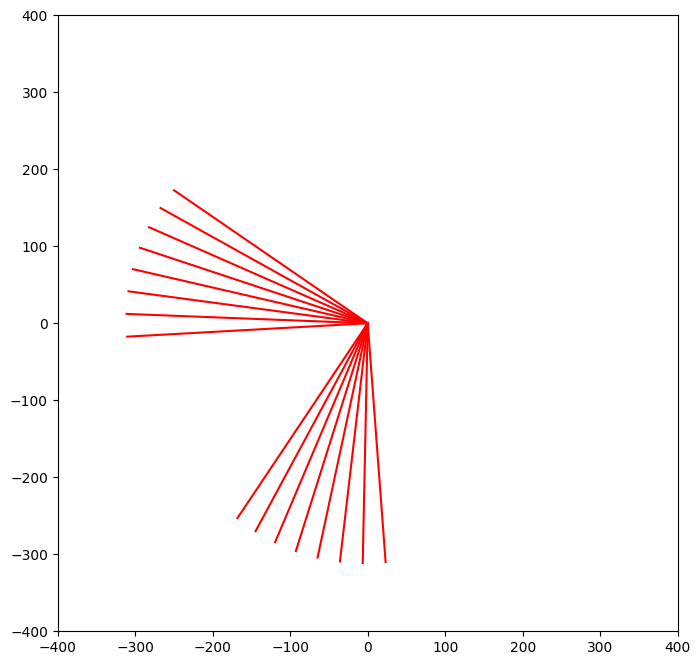

In [83]:
# Plot the rotated points
plt.figure(figsize=(8, 8))
plt.xlim(-400, 400)
plt.ylim(-400, 400)

for rotated_pose_set in zip(rotated_points_x, rotated_points_y):
    print(np.shape(rotated_pose_set[0]), np.shape(rotated_pose_set[1]))
    for rotated_point_x, rotated_point_y in zip(*rotated_pose_set):
        plt.plot([0, rotated_point_x], [0, rotated_point_y], 'r-')

In [102]:
# Now translate all rotated points for each pose, stack back into x, y pairs
translated = np.stack([rotated_points_x , rotated_points_y], axis=2)
print(np.shape(translated))
print(np.shape(try_poses[:, :2]))
# What we do here - we take 2 elements from the last axis of try_poses. We then interpose a new axis.
translated = translated + try_poses[:, np.newaxis, :2]
try_poses, translated

(2, 8, 2)
(2, 2)


(array([[1242.81508843,  442.25104022,    2.86651645],
        [ 943.32441592,   26.44727072,    4.45564088]]),
 array([[[ 992.89814474,  614.97690755],
         [ 975.49883301,  591.90960661],
         [ 960.73793115,  566.94080212],
         [ 948.82310989,  540.37246371],
         [ 939.92745688,  512.52921981],
         [ 934.18700762,  483.75439456],
         [ 931.69873083,  454.40577604],
         [ 932.5189974 ,  424.85116814]],
 
        [[ 775.20780712, -226.5932593 ],
         [ 798.59011241, -243.56689242],
         [ 823.82524752, -257.86770977],
         [ 850.60748755, -269.29360976],
         [ 878.6090864 , -277.67748329],
         [ 907.48428446, -282.88960982],
         [ 936.87357658, -284.83959415],
         [ 966.40818754, -283.47781563]]]))

In [103]:
offset_measurements = translated + np.array([margin, margin])
print(offset_measurements)

[[[1092.89814474  714.97690755]
  [1075.49883301  691.90960661]
  [1060.73793115  666.94080212]
  [1048.82310989  640.37246371]
  [1039.92745688  612.52921981]
  [1034.18700762  583.75439456]
  [1031.69873083  554.40577604]
  [1032.5189974   524.85116814]]

 [[ 875.20780712 -126.5932593 ]
  [ 898.59011241 -143.56689242]
  [ 923.82524752 -157.86770977]
  [ 950.60748755 -169.29360976]
  [ 978.6090864  -177.67748329]
  [1007.48428446 -182.88960982]
  [1036.87357658 -184.83959415]
  [1066.40818754 -183.47781563]]]


(3,) (8, 2)
(3,) (8, 2)


<Figure size 800x800 with 0 Axes>

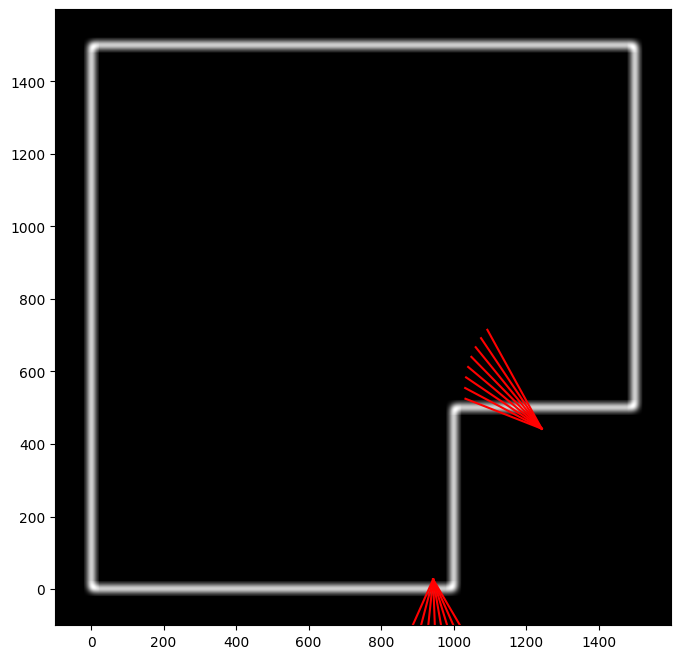

In [105]:
# Plot this
plt.figure(figsize=(8, 8))
plot_map(blurred_distance)
plt.xlim(wx_range[0], wx_range[-1])
plt.ylim(wy_range[0], wy_range[-1])

for pose ,pose_measurements in zip(try_poses, offset_measurements):
    print(np.shape(pose), np.shape(pose_measurements))
    for pose_measurement in pose_measurements:
        plt.plot([pose[0], pose_measurement[0]], [pose[1], pose_measurement[1]], 'r-')


In [135]:
def full_transform(input_readings, poses):
    # input readings - the distance readings, shape (8,)
    # poses - shape(n, 3) - x, y, theta
    sensor_reading_coordinates = sensor_readings_to_coordinates(input_readings)
    # TODO: Could we make a more general local points transform, once we've got coordinates?
    # Decompose
    poses_theta = poses[:,2]
    # Rotations for poses
    cos_th = np.cos(poses_theta)
    sin_th = np.sin(poses_theta)
    # Decompose readings
    local_points = sensor_reading_coordinates
    points_x = local_points[:,0]
    points_y = local_points[:,1]
    # Rotate the local points
    # The numpy outer is the "outer product", which takes all of the first list, and multiplies by all of the second list
    rotated_points_x = np.outer(cos_th, points_x) - np.outer(sin_th, points_y)
    rotated_points_y = np.outer(sin_th, points_x) + np.outer(cos_th, points_y)

    # Now translate all rotated points for each pose, stack back into x, y pairs
    translated = np.stack([rotated_points_x , rotated_points_y], axis=2)
    # What we do here - we take 2 elements from the last axis of try_poses. We then interpose a new axis.
    # result shape is n_poses, n_input_readings, 2
    translated = translated + poses[:, np.newaxis, :2]
    # Add the margin in (for the representation in the grid
    offset_measurements = translated + np.array([margin, margin])
    return offset_measurements
    

In [142]:
def plot_measurements(poses, measurement_coordinates, weight_map):
    # Poses - shape(n_poses, 3) - x, y, theta.
    # measurement_coordinates - (n_poses, n_readings, 2) - x, y.
    # weight_map - the input map field
    # Plot all poses on the map
    plt.figure(figsize=(8, 8))
    plot_map(weight_map)
    plt.xlim(wx_range[0], wx_range[-1])
    plt.ylim(wy_range[0], wy_range[-1])
    for pose ,pose_measurements in zip(poses, measurement_coordinates):
        for pose_measurement in pose_measurements:
            plt.plot([pose[0], pose_measurement[0]], [pose[1], pose_measurement[1]], 'r-')
    

In [137]:
# It seems like a vital point - thinking about the shape of the data will help you work things.
# With numpy, np.shape shows you an array shape.
# We can then use the shapes to see what we are getting. 
# For poses, the shape we have is (number of poses, 3) - where 3 is x, y and theta.
# For input measurments, the shape is number_of_measurements - in only 1 dimension.

# When we transform measurements, first we can get relative coordinates, that is, for each measurement, given a robot facing along X
# Which will be shape (number_of_measurements, 2) - where 2 maps to (x, y).

# We then need to rotate and translate this to each pose, making an intermediate structure (this is a large chunk of memory) 
# This is transformed_measurements - with shape (number_of_poses, number_of_mesaurements, 2) - where 2 maps to (x, y).

# We are ready then to look tehm up on the probability field - getting a probability for each transformed measurement. 
# The result- (number of poses, number of measurements)
# We can then evaluate all those measurement weights as a single pose weight, reducing the operation now
# shape - number_of_poses, with the one dimension being the combined weight.

# As a map-reduce flow!


Use poses: (19, 3) 
Measurement coordinates: (9, 8, 2)


<Figure size 800x800 with 0 Axes>

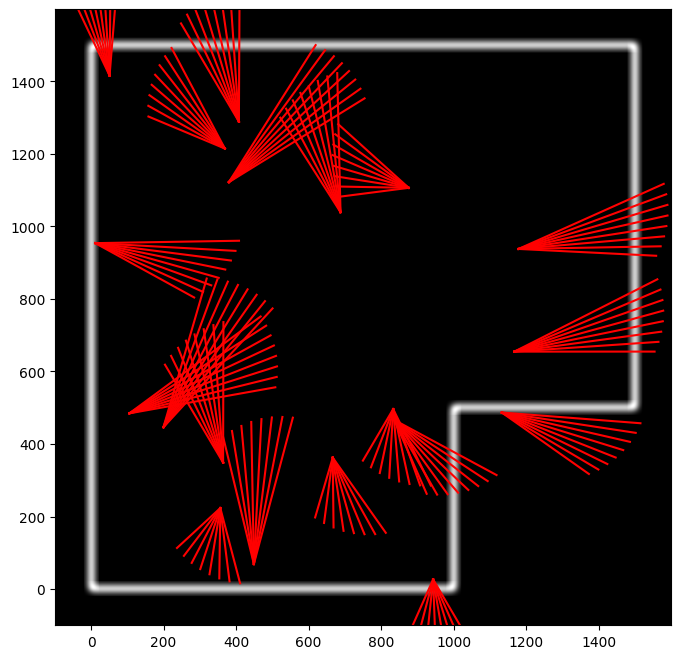

In [143]:
input_readings = np.array([257.0, 258.0, 259.0, 260.0, 261.0, 262.0, 263.0, 264.0])
use_poses = poses[1:20]
transformed_measurements = full_transform(input_readings, use_poses)
print("Use poses:", np.shape(use_poses), "\nMeasurement coordinates:", np.shape(measurement_coordinates))
plot_measurements(use_poses, transformed_measurements, blurred_distance)

In [ ]:
# Weight is based on if any measurements are probably - any means addition. 
